In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score

# STEP 1: PREPROCESSING & FEATURE SELECTION

In [9]:
df = pd.read_csv('C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/Imbalance correction/balanced_edufeed_dataset_FINAL.csv')
print(f" Initial Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

 Initial Dataset Loaded: 35421 rows, 62 columns


In [12]:
tag_cols = ['gives_good_feedback', 'caring', 'respected', 'participation_matters',
            'clear_grading_criteria', 'skip_class', 'amazing_lectures', 'inspirational',
            'tough_grader', 'hilarious', 'get_ready_to_read', 'lots_of_homework',
            'accessible_outside_class', 'lecture_heavy', 'extra_credit',
            'graded_by_few_things', 'group_projects', 'test_heavy', 'so_many_papers',
            'beware_of_pop_quizzes', 'IsCourseOnline']
features = ['student_difficult', 'diff_index', 'take_again', 
            'help_ratio', 'tag_count', 'word_comment'] + tag_cols
target = 'student_star'


In [14]:
cols_to_drop = ['race', 'gender', 'asian', 'hispanic', 'nh_black', 'nh_white']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
df_model = df_clean.dropna(subset=features + [target])

print(f" Demographic columns removed for anonymity.")
print(f" Rows after dropping null values: {len(df_model)}")
print(f" Total features being used: {len(features)}")

 Demographic columns removed for anonymity.
 Rows after dropping null values: 35421
 Total features being used: 27


# STEP 2: FILE EXPORT (CSV & XLSX)

In [15]:
df_model.to_csv('edfeed_cleaned_rating_features.csv', index=False)
df_model.to_excel('edfeed_cleaned_rating_features.xlsx', index=False)
print("[✓] Processed modeling data saved as .csv and .xlsx")

[✓] Processed modeling data saved as .csv and .xlsx


# STEP 3: MODEL TRAINING & EVALUATION

In [18]:
X= df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression (Baseline 1)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print(f"\n[MODEL 1: LINEAR REGRESSION]")
print(f"  - MAE  : {mean_absolute_error(y_test, lr_preds):.4f}")
print(f"  - RMSE : {np.sqrt(mean_squared_error(y_test, lr_preds)):.4f}")
print(f"  - R2   : {r2_score(y_test, lr_preds):.4f}")

#  Random Forest (Baseline 2) 
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print(f"\n[MODEL 2: RANDOM FOREST REGRESSOR]")
print(f"  - MAE  : {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"  - RMSE : {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")
print(f"  - R2   : {r2_score(y_test, rf_preds):.4f}")


[MODEL 1: LINEAR REGRESSION]
  - MAE  : 0.9791
  - RMSE : 1.1861
  - R2   : 0.2262

[MODEL 2: RANDOM FOREST REGRESSOR]
  - MAE  : 0.6158
  - RMSE : 0.9602
  - R2   : 0.4928


# STEP 4: VISUALIZATION & PLOT SAVING

 Feature Importance plot saved as 'rating_feature_importance.png'


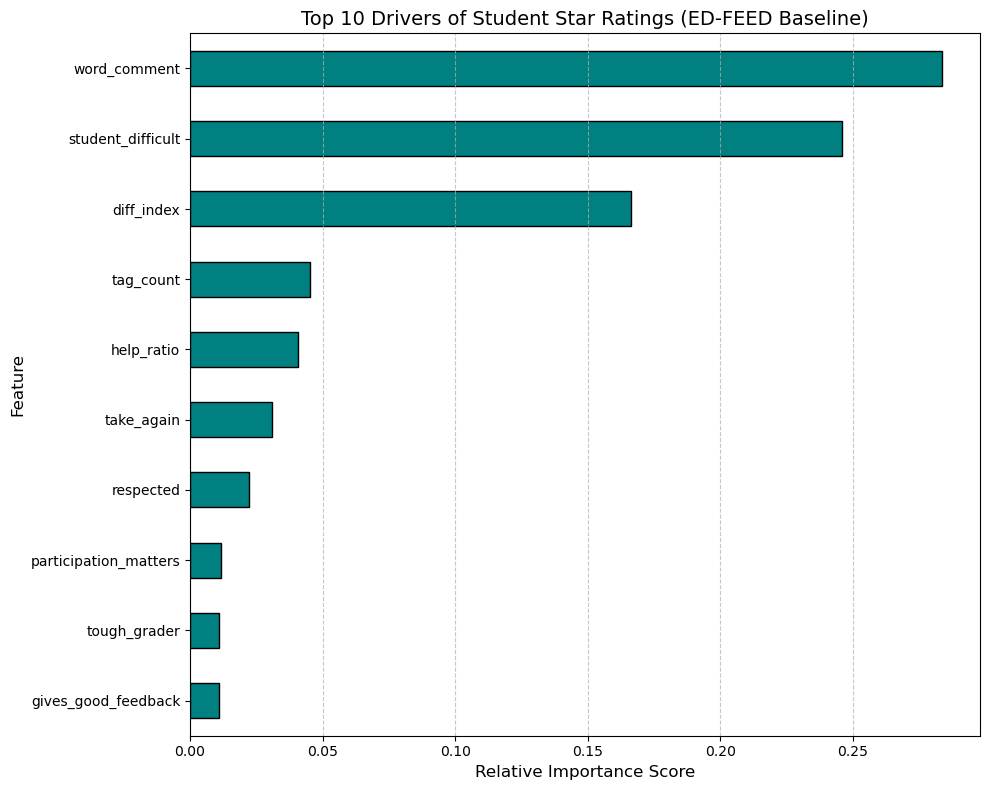

In [20]:
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True).tail(10)
feat_importances.plot(kind='barh', color='teal', edgecolor='black')

plt.title("Top 10 Drivers of Student Star Ratings (ED-FEED Baseline)", fontsize=14)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('rating_feature_importance.png', dpi=300)
print(" Feature Importance plot saved as 'rating_feature_importance.png'")
plt.show()

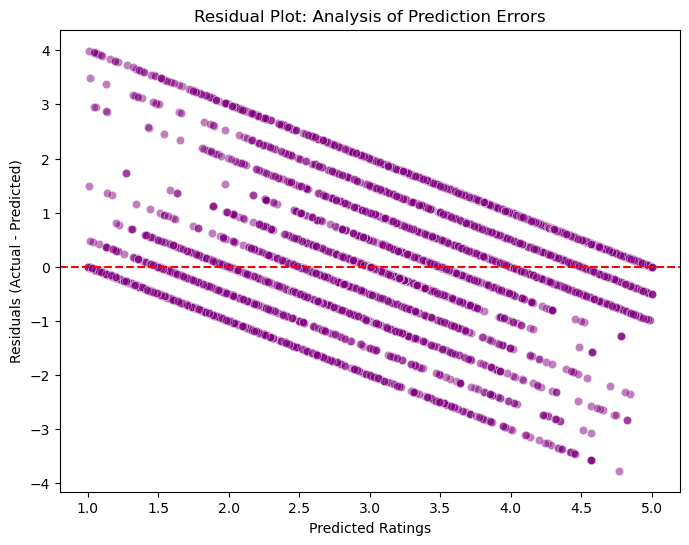

In [21]:
residuals = y_test - rf_preds
plt.figure(figsize=(8, 6))
sns.scatterplot(x=rf_preds, y=residuals, alpha=0.5, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot: Analysis of Prediction Errors")
plt.xlabel("Predicted Ratings")
plt.ylabel("Residuals (Actual - Predicted)")
plt.savefig('rf_residuals.png')
plt.show()

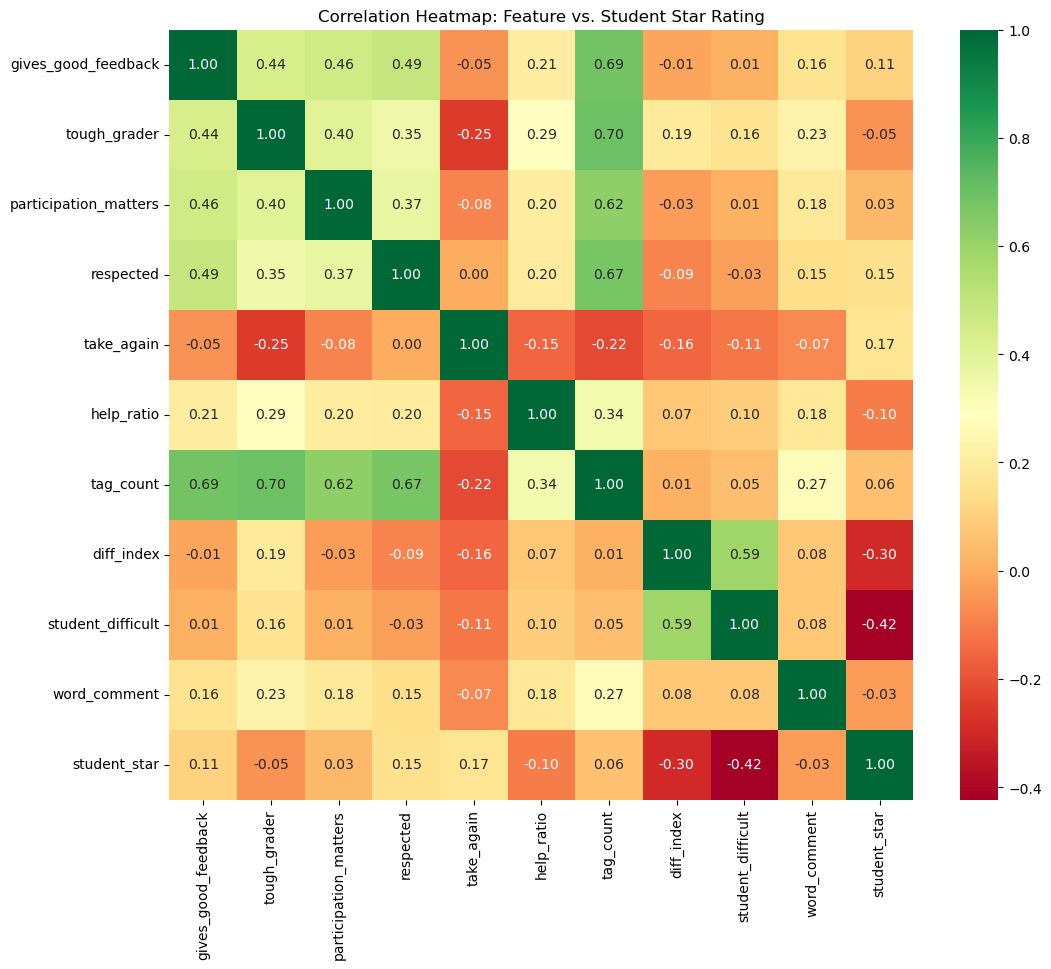

In [22]:
top_features = feat_importances.index.tolist() + [target]
plt.figure(figsize=(12, 10))
sns.heatmap(df_model[top_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation Heatmap: Feature vs. Student Star Rating")
plt.savefig('feature_correlation_heatmap.png')
plt.show()

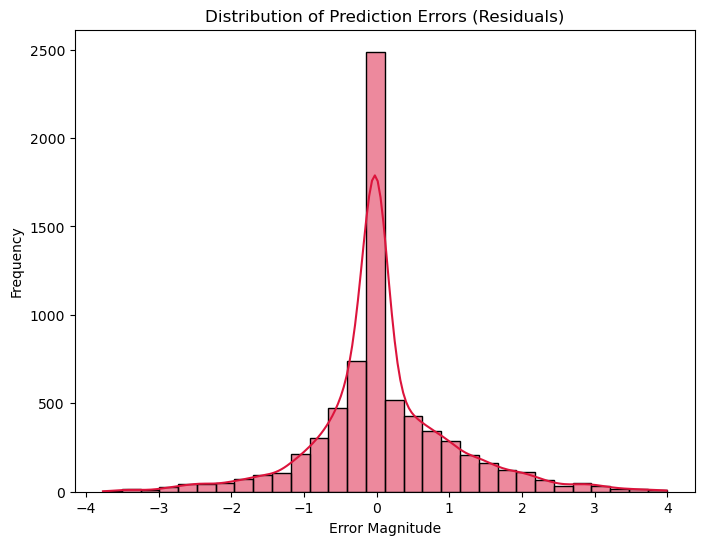

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='crimson', bins=30)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error Magnitude")
plt.ylabel("Frequency")
plt.savefig('error_distribution.png')
plt.show()

C:\Users\TANZEEM\AppData\Local\Temp\ipykernel_10684\2060575829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tough_grader', y='student_star', data=df_model, palette='Set2')


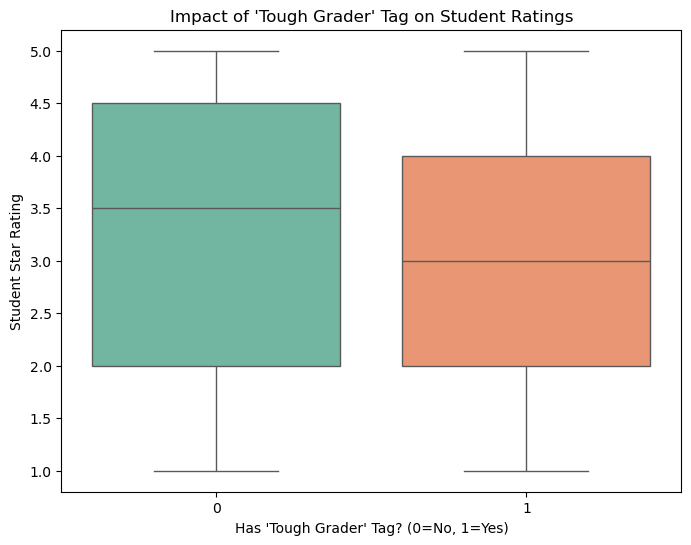

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='tough_grader', y='student_star', data=df_model, palette='Set2')
plt.title("Impact of 'Tough Grader' Tag on Student Ratings")
plt.xlabel("Has 'Tough Grader' Tag? (0=No, 1=Yes)")
plt.ylabel("Student Star Rating")
plt.savefig('tag_impact_boxplot.png')
plt.show()